In [2]:
import pandas as pd

# Read the data
cancerData = pd.read_csv("Cancer_Data.csv")
cancerData.head()

,id,diagnosis,radius_mean,texture_mean,perimeter_mean,area_mean,smoothness_mean,compactness_mean,concavity_mean,concave points_mean,...,texture_worst,perimeter_worst,area_worst,smoothness_worst,compactness_worst,concavity_worst,concave points_worst,symmetry_worst,fractal_dimension_worst,Unnamed: 32
0,842302,M,17.99,10.38,122.80,1001.0,0.11840,0.27760,0.3001,0.14710,...,17.33,184.60,2019.0,0.1622,0.6656,0.7119,0.2654,0.4601,0.11890,NaN
1,842517,M,20.57,17.77,132.90,1326.0,0.08474,0.07864,0.0869,0.07017,...,23.41,158.80,1956.0,0.1238,0.1866,0.2416,0.1860,0.2750,0.08902,NaN
2,84300903,M,19.69,21.25,130.00,1203.0,0.10960,0.15990,0.1974,0.12790,...,25.53,152.50,1709.0,0.1444,0.4245,0.4504,0.2430,0.3613,0.08758,NaN
3,84348301,M,11.42,20.38,77.58,386.1,0.14250,0.28390,0.2414,0.10520,...,26.50,98.87,567.7,0.2098,0.8663,0.6869,0.2575,0.6638,0.17300,NaN
4,84358402,M,20.29,14.34,135.10,1297.0,0.10030,0.13280,0.1980,0.10430,...,16.67,152.20,1575.0,0.1374,0.2050,0.4000,0.1625,0.2364,0.07678,NaN


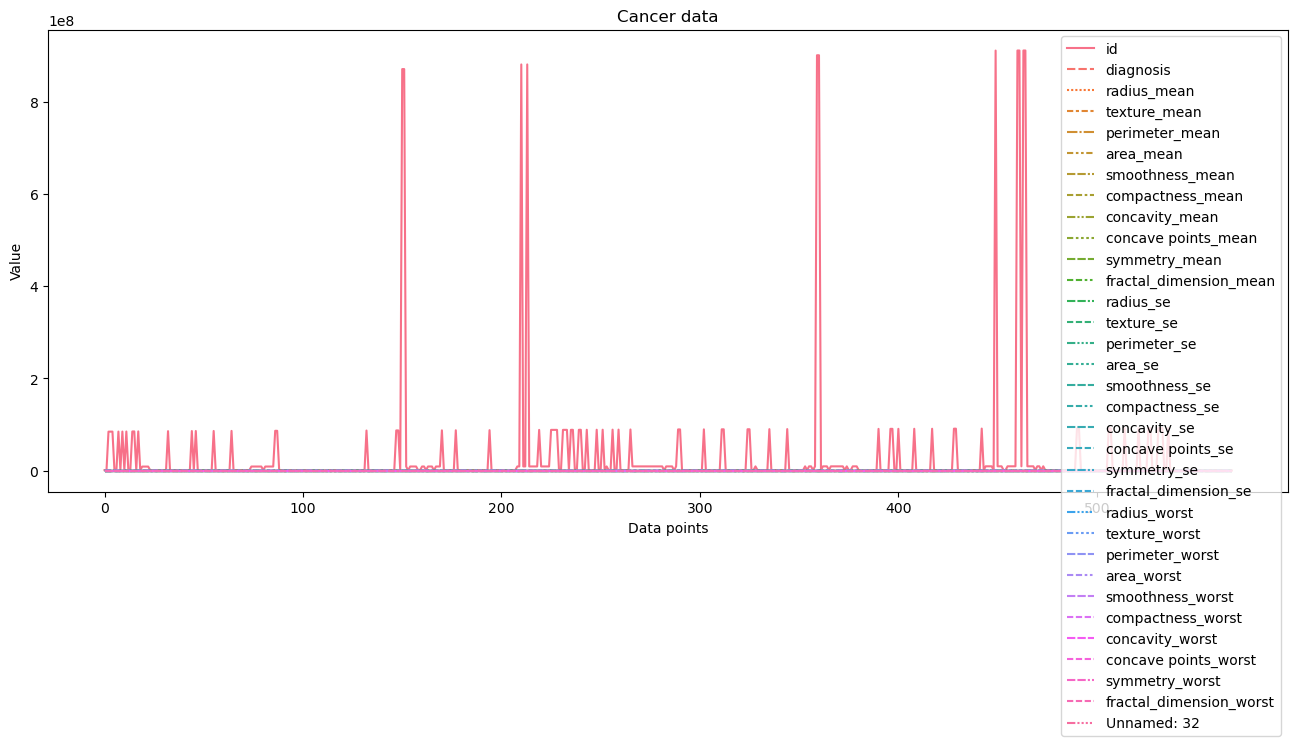

In [22]:
pd.plotting.register_matplotlib_converters()
import matplotlib.pyplot as plt
%matplotlib inline
import seaborn as sns

# Set the width and height of the figure
plt.figure(figsize=(16,6))

# Add title
plt.title("Cancer data")

# Line chart showing how values and datapoints
sns.lineplot(data=cancerData)

# Add label for horizontal axis
plt.ylabel("Value")
plt.xlabel("Data points")
plt.show()

In [4]:
cancerData['diagnosis'] = cancerData['diagnosis'].map({"M":0, "B":1})

In [5]:
# Separate target from predictors
y = cancerData.diagnosis
X = cancerData.copy()
# X.drop(['diagnosis','id','Unnamed: 32','texture_se','smoothness_se'], axis=1, inplace=True)
X.drop(['diagnosis', 'id', 'concavity_se', 'fractal_dimension_se', 'smoothness_se', 'texture_se','Unnamed: 32'], axis=1, inplace=True)

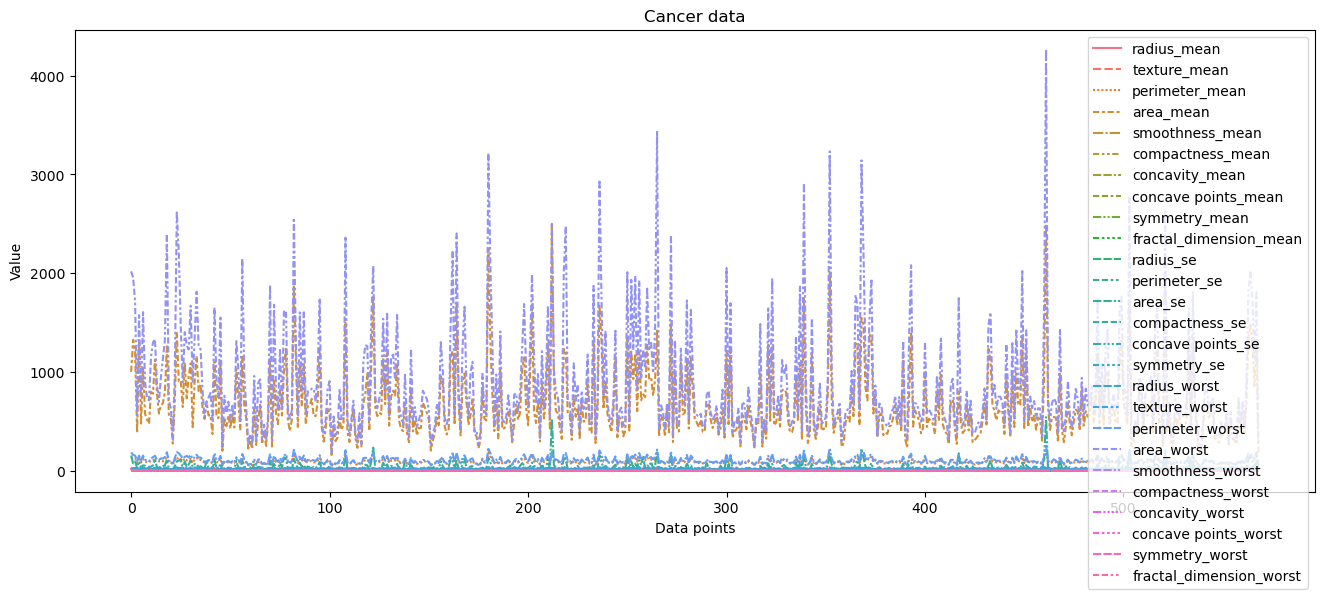

In [23]:
# Set the width and height of the figure
plt.figure(figsize=(16,6))

# Add title
plt.title("Cancer data")

# Line chart showing how values and datapoints
sns.lineplot(data=X)

# Add label for horizontal axis
plt.ylabel("Value")
plt.xlabel("Data points")
plt.show()

In [7]:
# Break off validation set from training data

from sklearn.model_selection import train_test_split

X_train, X_valid, y_train, y_valid = train_test_split(X, y, train_size= 0.8, test_size= 0.2, random_state=0)

In [8]:
X_train.head()

,radius_mean,texture_mean,perimeter_mean,area_mean,smoothness_mean,compactness_mean,concavity_mean,concave points_mean,symmetry_mean,fractal_dimension_mean,...,radius_worst,texture_worst,perimeter_worst,area_worst,smoothness_worst,compactness_worst,concavity_worst,concave points_worst,symmetry_worst,fractal_dimension_worst
338,10.05,17.53,64.41,310.8,0.10070,0.07326,0.02511,0.01775,0.1890,0.06331,...,11.16,26.84,71.98,384.0,0.1402,0.14020,0.1055,0.06499,0.2894,0.07664
427,10.80,21.98,68.79,359.9,0.08801,0.05743,0.03614,0.01404,0.2016,0.05977,...,12.76,32.04,83.69,489.5,0.1303,0.16960,0.1927,0.07485,0.2965,0.07662
406,16.14,14.86,104.30,800.0,0.09495,0.08501,0.05500,0.04528,0.1735,0.05875,...,17.71,19.58,115.90,947.9,0.1206,0.17220,0.2310,0.11290,0.2778,0.07012
96,12.18,17.84,77.79,451.1,0.10450,0.07057,0.02490,0.02941,0.1900,0.06635,...,12.83,20.92,82.14,495.2,0.1140,0.09358,0.0498,0.05882,0.2227,0.07376
490,12.25,22.44,78.18,466.5,0.08192,0.05200,0.01714,0.01261,0.1544,0.05976,...,14.17,31.99,92.74,622.9,0.1256,0.18040,0.1230,0.06335,0.3100,0.08203


In [9]:
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import OneHotEncoder
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import mean_absolute_error

In [10]:
# Preprocessing for numerical data
numerical_transformer = SimpleImputer(strategy='constant')

In [11]:
# Define model
model = RandomForestClassifier(n_estimators=100, random_state=0)

In [12]:
# Bundle preprocessing and modeling code in a pipeline
clf = Pipeline(steps=[('preprocessor', numerical_transformer),
                      ('model', model)
                     ])


In [13]:
# Preprocessing of training data, fit model 
clf.fit(X_train, y_train)

Pipeline(steps=[('preprocessor', SimpleImputer(strategy='constant')),
                ('model', RandomForestClassifier(random_state=0))])

In [14]:
# Preprocessing of validation data, get predictions
preds = clf.predict(X_valid)

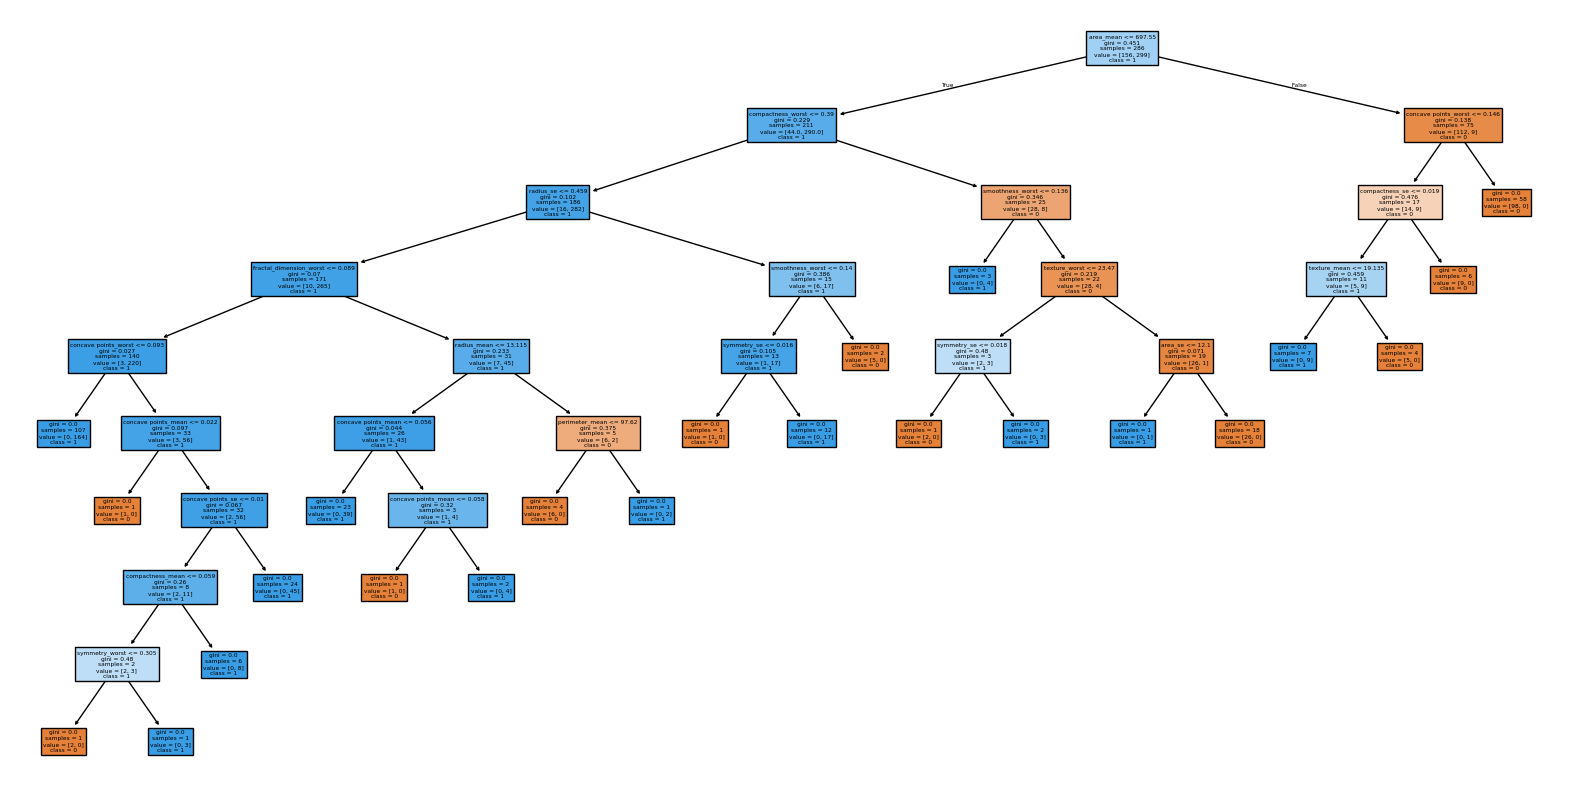

In [27]:
from sklearn.tree import plot_tree

# Visualize the first tree
plt.figure(figsize=(20, 10))
plot_tree(model.estimators_[0], #change value to see a diffrent tree
          filled=True, 
          feature_names=X.columns, 
          class_names=[str(cls) for cls in model.classes_])  # Convert to strings
plt.show()

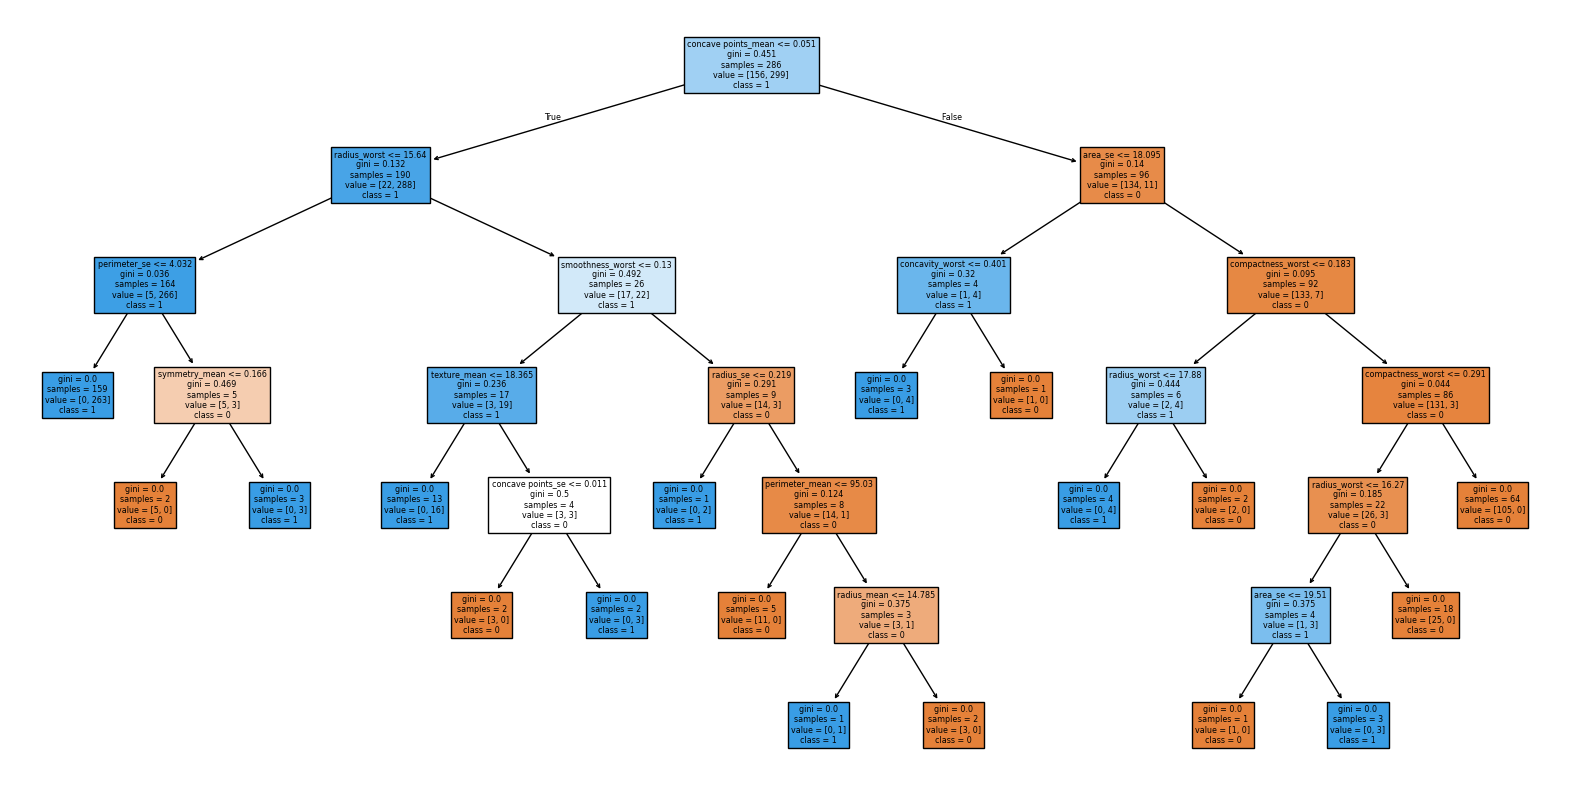

In [26]:
# Visualize the second tree
plt.figure(figsize=(20, 10))
plot_tree(model.estimators_[1], #change value to see a diffrent tree
          filled=True, 
          feature_names=X.columns, 
          class_names=[str(cls) for cls in model.classes_])  # Convert to strings
plt.show()

In [ ]:
print('MAE:', mean_absolute_error(y_valid, preds))

MAE: 0.03508771929824561


In [ ]:
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report

In [ ]:
print("Accuracy:", accuracy_score(y_valid, preds))
print("Confusion Matrix:\n", confusion_matrix(y_valid, preds))
print("Classification Report:\n", classification_report(y_valid, preds))

Accuracy: 0.9649122807017544
Confusion Matrix:
 [[46  1]
 [ 3 64]]
Classification Report:
               precision    recall  f1-score   support

           0       0.94      0.98      0.96        47
           1       0.98      0.96      0.97        67

    accuracy                           0.96       114
   macro avg       0.96      0.97      0.96       114
weighted avg       0.97      0.96      0.97       114

